# BERT-base-uncased ABSA Pipeline

Two-stage pipeline:
- Stage 1: Aspect Term Extraction (ATE) using BertForTokenClassification with BIO tagging
- Stage 2: Aspect Sentiment Classification (ASC) using BertForSequenceClassification

Training data: SemEval 2014 (restaurants + laptops), Hotels.xml, MAMS-ACSA (train + test)
Yelp reviews are used for ASC only (star-rating-guided sampling to fix class imbalance).

References:
- Devlin et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers. NAACL 2019.
- Pontiki et al. (2014). SemEval-2014 Task 4: Aspect Based Sentiment Analysis. SemEval 2014.
- Jiang et al. (2019). MAMS: A Dataset for Multi-Aspect Multi-Sentiment Analysis. EMNLP 2019.
- Sun et al. (2019). Utilizing BERT for ABSA via Constructing Auxiliary Sentence. NAACL 2019.

## 1. Imports and Device Setup

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import torch
import random
import re
import os
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from torch.utils.data import Dataset
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    BertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')

d:\PBL Project Updated\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0322 00:11:35.645000 16892 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


PyTorch: 2.10.0+cu126
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.59 GB


## 2. Constants

In [2]:
MODEL_CHECKPOINT   = 'bert-base-uncased'
MODEL_KEY          = 'bert'
ATE_OUTPUT_DIR     = './bert_ate_model'
SENT_OUTPUT_DIR    = './bert_sentiment_model'
ATE_FINAL_DIR      = './bert_ate_model_final'
SENT_FINAL_DIR     = './bert_sentiment_model_final'

ATE_LABEL_MAP      = {'O': 0, 'B-ASP': 1, 'I-ASP': 2}
ATE_LABEL_NAMES    = ['O', 'B-ASP', 'I-ASP']
SENT_LABEL_MAP     = {'positive': 0, 'negative': 1, 'neutral': 2, 'conflict': 3}
SENT_LABEL_NAMES   = ['positive', 'negative', 'neutral', 'conflict']
SCORE_MAP          = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0, 'conflict': -0.5}
SCORE_VEC          = np.array([SCORE_MAP[l] for l in SENT_LABEL_NAMES])

# MAMS category -> ABSA normalised aspect
MAMS_CAT_MAP = {
    'food':          'food',
    'staff':         'service',
    'service':       'service',
    'price':         'value',
    'ambience':      'ambiance',
    'place':         'ambiance',
    'menu':          'quality',
    'miscellaneous': 'experience',
}

print('Constants set. Model:', MODEL_CHECKPOINT)

Constants set. Model: bert-base-uncased


## 3. Data Loading

Loads four sources:
1. SemEval 2014 Restaurants test gold
2. SemEval 2014 Laptops test gold
3. Hotels.xml (SemEval 2016 format)
4. MAMS-ACSA train.xml and test.xml

MAMS is critical because every sentence contains at least two aspect categories
with different polarities, directly fixing the conflict and neutral class imbalance
identified in the baseline model (neutral F1=0.82, conflict recall=0.80).
Reference: Jiang et al. (2019). MAMS: A Dataset for Multi-Aspect Multi-Sentiment.

In [3]:
def parse_semeval_xml(filepath):
    """Parse SemEval 2014 format: aspectTerms with char offsets."""
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for sentence in root.findall('sentence'):
        text_node = sentence.find('text')
        if text_node is None or not text_node.text:
            continue
        text = text_node.text
        aspects = []
        aspect_terms = sentence.find('aspectTerms')
        if aspect_terms is not None:
            for asp in aspect_terms.findall('aspectTerm'):
                term     = asp.get('term', '').strip()
                polarity = asp.get('polarity', '').strip().lower()
                cf       = int(asp.get('from', 0))
                ct       = int(asp.get('to', 0))
                if term and polarity in SENT_LABEL_MAP:
                    aspects.append((term, polarity, cf, ct))
        records.append({'text': text, 'aspects': aspects, 'source': 'semeval'})
    return records


def parse_hotels_xml(filepath):
    """Parse Hotels.xml (SemEval 2016 format)."""
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for review in root.findall('Review'):
        for sentence in review.find('sentences').findall('sentence'):
            text_node = sentence.find('text')
            if text_node is None or not text_node.text:
                continue
            text = text_node.text
            aspects = []
            opinions = sentence.find('Opinions')
            if opinions is not None:
                for op in opinions.findall('Opinion'):
                    term     = op.get('target', '').strip()
                    polarity = op.get('polarity', '').strip().lower()
                    cf       = int(op.get('target_from', 0))
                    ct       = int(op.get('target_to', 0))
                    if term and term != 'NULL' and polarity in SENT_LABEL_MAP:
                        aspects.append((term, polarity, cf, ct))
            records.append({'text': text, 'aspects': aspects, 'source': 'hotels'})
    return records


def parse_mams_xml(filepath):
    """
    Parse MAMS-ACSA XML.
    MAMS uses aspectCategories (category + polarity) without char offsets.
    We use the category name as a pseudo-aspect term for the ASC task.
    For the ATE task these records are excluded (no char offsets available).
    """
    tree = ET.parse(filepath)
    root = tree.getroot()
    records = []
    for sentence in root.findall('sentence'):
        text_node = sentence.find('text')
        if text_node is None or not text_node.text:
            continue
        text = text_node.text.strip()
        aspects = []
        for ac in sentence.findall('aspectCategories/aspectCategory'):
            cat      = ac.get('category', '').strip().lower()
            polarity = ac.get('polarity', '').strip().lower()
            # Map MAMS categories to normalised aspect term
            term = MAMS_CAT_MAP.get(cat, cat)
            if polarity in SENT_LABEL_MAP:
                # -1 offsets signal that this is a category record (no char span)
                aspects.append((term, polarity, -1, -1))
        if aspects:
            records.append({'text': text, 'aspects': aspects, 'source': 'mams'})
    return records


# Load all sources
restaurant_data = parse_semeval_xml('Restaurants_Test_Gold.xml')
laptop_data     = parse_semeval_xml('Laptops_Test_Gold.xml')
hotel_data      = parse_hotels_xml('Hotels.xml')
mams_train      = parse_mams_xml('train.xml')
mams_test       = parse_mams_xml('test.xml')

# All data for ASC (includes MAMS)
all_data_asc = restaurant_data + laptop_data + hotel_data + mams_train + mams_test

# ATE data only: records that have real char offsets (exclude MAMS)
all_data_ate = restaurant_data + laptop_data + hotel_data

print(f'Restaurant: {len(restaurant_data)} sentences')
print(f'Laptop:     {len(laptop_data)} sentences')
print(f'Hotels:     {len(hotel_data)} sentences')
print(f'MAMS train: {len(mams_train)} sentences')
print(f'MAMS test:  {len(mams_test)} sentences')
print(f'Total ATE data: {len(all_data_ate)} sentences')
print(f'Total ASC data: {len(all_data_asc)} sentences')

Restaurant: 800 sentences
Laptop:     800 sentences
Hotels:     9793 sentences
MAMS train: 3149 sentences
MAMS test:  400 sentences
Total ATE data: 11393 sentences
Total ASC data: 14942 sentences


## 4. Yelp Review Sampling for ASC

yelp_academic_dataset_review.json is used to oversample neutral and negative reviews.
We sample a balanced subset guided by star ratings:
- Stars 1-2 -> negative
- Star 3    -> neutral
- Stars 4-5 -> positive

We cap at 5000 per class to keep training time reasonable on a laptop GPU.
Each Yelp review contributes one ASC record with the review category as the aspect term.
The category comes from yelp_academic_dataset_business.json category field if available;
otherwise we use 'overall' as the aspect term.

Reference: Yelp Open Dataset. https://www.yelp.com/dataset

In [4]:
YELP_REVIEW_PATH   = 'yelp_academic_dataset_review.json'
YELP_SAMPLES_PER_CLASS = 5000   # cap per sentiment class
YELP_MAX_TEXT_LEN  = 300        # characters; skip very long reviews

def load_yelp_asc_records(review_path, samples_per_class=5000, max_text_len=300):
    """
    Stream yelp_academic_dataset_review.json and sample balanced ASC records.
    Star ratings map to polarities:
        1,2 -> negative   3 -> neutral   4,5 -> positive
    Returns a list of ASC-format dicts compatible with build_sentiment_records output.
    """
    buckets = {'positive': [], 'negative': [], 'neutral': []}
    needed  = {'positive': samples_per_class,
                'negative': samples_per_class,
                'neutral':  samples_per_class}

    def star_to_polarity(stars):
        if stars in (1, 2): return 'negative'
        if stars == 3:      return 'neutral'
        return 'positive'

    print(f'Streaming {review_path} ...')
    with open(review_path, 'r', encoding='utf-8') as f:
        for line in f:
            # Stop early if all buckets are full
            if all(len(buckets[p]) >= needed[p] for p in buckets):
                break
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            text  = obj.get('text', '').replace('\n', ' ').strip()
            stars = int(obj.get('stars', 0))
            if not text or len(text) > max_text_len or stars == 0:
                continue
            pol = star_to_polarity(stars)
            if len(buckets[pol]) < needed[pol]:
                # Use 'overall' as the aspect term for full-review Yelp records
                buckets[pol].append({
                    'combined_text': f'overall [SEP] {text}',
                    'aspect':        'overall',
                    'text':          text,
                    'label':         SENT_LABEL_MAP[pol],
                    'polarity':      pol,
                })

    records = []
    for pol, recs in buckets.items():
        records.extend(recs)
        print(f'  {pol}: {len(recs)} records')
    return records


yelp_records = []
if os.path.exists(YELP_REVIEW_PATH):
    yelp_records = load_yelp_asc_records(
        YELP_REVIEW_PATH,
        samples_per_class=YELP_SAMPLES_PER_CLASS,
        max_text_len=YELP_MAX_TEXT_LEN
    )
    print(f'Total Yelp ASC records: {len(yelp_records)}')
else:
    print(f'WARNING: {YELP_REVIEW_PATH} not found. Training without Yelp data.')
    print('Place yelp_academic_dataset_review.json in the same directory as this notebook.')

Streaming yelp_academic_dataset_review.json ...
  positive: 5000 records
  negative: 5000 records
  neutral: 5000 records
Total Yelp ASC records: 15000


## 5. Build Sentiment Records

In [5]:
def build_sentiment_records(data):
    """Convert parsed records to flat (combined_text, label) rows for ASC."""
    rows = []
    for record in data:
        text = record['text']
        for (term, polarity, _, _) in record['aspects']:
            combined = f'{term} [SEP] {text}'
            rows.append({
                'combined_text': combined,
                'aspect':        term,
                'text':          text,
                'label':         SENT_LABEL_MAP[polarity],
                'polarity':      polarity,
            })
    return rows


base_sent_records = build_sentiment_records(all_data_asc)
df_sentiment      = pd.DataFrame(base_sent_records + yelp_records)

print(f'Total sentiment records: {len(df_sentiment)}')
print('Polarity distribution:')
print(df_sentiment['polarity'].value_counts())

Total sentiment records: 33360
Polarity distribution:
polarity
positive    15427
neutral      9007
negative     8892
conflict       34
Name: count, dtype: int64


## 6. Build ATE Records (BIO labels)

In [6]:
def build_bio_labels(text, aspects):
    """Assign B-ASP / I-ASP / O to each word using character offsets."""
    words         = text.split()
    aspect_chars  = set()
    aspect_starts = set()
    for (term, polarity, cf, ct) in aspects:
        if cf < 0:
            continue  # MAMS records have no char offsets
        for c in range(cf, ct):
            aspect_chars.add(c)
        aspect_starts.add(cf)
    word_labels = []
    char_pos    = 0
    for word in words:
        ws  = char_pos
        we  = char_pos + len(word)
        in_asp  = any(c in aspect_chars for c in range(ws, we))
        is_beg  = ws in aspect_starts
        if in_asp and is_beg:
            word_labels.append('B-ASP')
        elif in_asp:
            word_labels.append('I-ASP')
        else:
            word_labels.append('O')
        char_pos = we + 1
    return words, word_labels


def build_ate_records(data):
    records = []
    for record in data:
        if not record['aspects'] or all(a[2] < 0 for a in record['aspects']):
            words = record['text'].split()
            bio   = ['O'] * len(words)
        else:
            words, bio = build_bio_labels(record['text'], record['aspects'])
        records.append({'words': words, 'bio_labels': bio, 'text': record['text']})
    return records


ate_records = build_ate_records(all_data_ate)
all_bio     = [lbl for r in ate_records for lbl in r['bio_labels']]
print(f'ATE records: {len(ate_records)}')
print('BIO distribution:', Counter(all_bio))

ATE records: 11393
BIO distribution: Counter({'O': 160555, 'B-ASP': 8225, 'I-ASP': 2606})


## 7. Augmentation

In [7]:
SYNONYMS = {
    'good': ['great', 'nice', 'decent', 'solid'],
    'bad': ['poor', 'terrible', 'awful', 'weak'],
    'great': ['excellent', 'wonderful', 'fantastic', 'superb'],
    'fast': ['quick', 'speedy', 'swift', 'rapid'],
    'slow': ['sluggish', 'delayed', 'laggy'],
    'expensive': ['pricey', 'costly', 'overpriced'],
    'cheap': ['affordable', 'budget-friendly', 'inexpensive'],
    'delicious': ['tasty', 'flavorful', 'scrumptious'],
    'friendly': ['pleasant', 'welcoming', 'warm'],
    'awful': ['terrible', 'horrible', 'dreadful'],
    'love': ['enjoy', 'like', 'adore'],
    'hate': ['dislike', 'despise', 'loathe'],
    'fresh': ['new', 'clean', 'crisp'],
    'old': ['outdated', 'aged', 'worn'],
    'beautiful': ['lovely', 'gorgeous', 'attractive'],
}
FILLER_WORDS = ['really', 'very', 'quite', 'honestly', 'actually', 'basically', 'generally']


def synonym_replacement(words, bio_labels, n=1):
    nw, nl    = words.copy(), bio_labels.copy()
    cands     = [i for i, l in enumerate(bio_labels) if l == 'O']
    random.shuffle(cands)
    replaced  = 0
    for idx in cands:
        w = words[idx].lower().strip('.,!?')
        if w in SYNONYMS:
            nw[idx] = random.choice(SYNONYMS[w])
            replaced += 1
        if replaced >= n:
            break
    return nw, nl


def random_insertion(words, bio_labels):
    if not words:
        return words, bio_labels
    o_pos = [i for i, l in enumerate(bio_labels) if l == 'O']
    if not o_pos:
        return words, bio_labels
    ip = random.choice(o_pos)
    fw = random.choice(FILLER_WORDS)
    return words[:ip] + [fw] + words[ip:], bio_labels[:ip] + ['O'] + bio_labels[ip:]


def random_deletion(words, bio_labels, p=0.1):
    if len(words) <= 2:
        return words, bio_labels
    nw, nl = [], []
    for w, l in zip(words, bio_labels):
        if l == 'O' and random.random() < p:
            continue
        nw.append(w); nl.append(l)
    return (nw, nl) if nw else (words, bio_labels)


AUG_FNS = {'synonym': synonym_replacement,
            'insert':  random_insertion,
            'delete':  random_deletion}

augmented_ate = list(ate_records)
for rec in ate_records:
    if any(l != 'O' for l in rec['bio_labels']):
        fn_name = random.choice(list(AUG_FNS.keys()))
        nw, nl  = AUG_FNS[fn_name](rec['words'], rec['bio_labels'])
        augmented_ate.append({'words': nw, 'bio_labels': nl, 'text': ' '.join(nw)})

print(f'ATE records after augmentation: {len(augmented_ate)}')

# Augment ASC records (non-Yelp only to avoid corrupting clean review text)
aug_sent_rows = []
for _, row in pd.DataFrame(base_sent_records).iterrows():
    words   = row['text'].split()
    fn_name = random.choice(list(AUG_FNS.keys()))
    nw, _   = AUG_FNS[fn_name](words, ['O'] * len(words))
    nt      = ' '.join(nw)
    aug_sent_rows.append({
        'combined_text': f"{row['aspect']} [SEP] {nt}",
        'aspect': row['aspect'], 'text': nt,
        'label': row['label'], 'polarity': row['polarity'],
    })

df_sentiment_aug = pd.concat(
    [df_sentiment, pd.DataFrame(aug_sent_rows)], ignore_index=True
)
print(f'Sentiment records after augmentation: {len(df_sentiment_aug)}')

ATE records after augmentation: 17220
Sentiment records after augmentation: 51720


## 8. Bad Data Injection and Cleaning

In [8]:
def add_misspellings(text):
    words = text.split()
    if not words: return text
    idx  = random.randint(0, len(words) - 1)
    word = list(words[idx])
    if len(word) >= 2:
        s = random.randint(0, len(word) - 2)
        word[s], word[s+1] = word[s+1], word[s]
    words[idx] = ''.join(word)
    return ' '.join(words)

def add_random_tokens(text):
    garbage = ['###', '...', '???', '!!!', 'xjfk', '@@@@']
    words   = text.split()
    pos     = random.randint(0, len(words))
    words.insert(pos, random.choice(garbage))
    return ' '.join(words)

def break_punctuation(text):
    if random.random() < 0.5:
        return re.sub(r'[.,!?;:]', '', text)
    return text.replace('.', '...')

BAD_FNS = [add_misspellings, add_random_tokens, break_punctuation]

num_bad  = max(10, int(len(df_sentiment_aug) * 0.1))
bad_rows = []
for idx in random.sample(range(len(df_sentiment_aug)), num_bad):
    row = df_sentiment_aug.iloc[idx].copy()
    fn  = random.choice(BAD_FNS)
    row['combined_text'] = fn(row['combined_text'])
    row['text']          = fn(row['text'])
    row['is_bad']        = True
    bad_rows.append(row)

df_sentiment_aug['is_bad'] = False
df_with_bad = pd.concat([df_sentiment_aug, pd.DataFrame(bad_rows)], ignore_index=True)

GARBAGE_PAT = re.compile(r'(#{2,}|@{2,}|\?{3,}|!{3,}|[a-z]{4,}[fjkxz]{3,})', re.IGNORECASE)

def detect_bad_text(text):
    if not isinstance(text, str): return True
    words = text.split()
    if len(words) < 3 or len(words) > 100: return True
    if GARBAGE_PAT.search(text): return True
    alpha = sum(1 for c in text if c.isalpha())
    if len(text) > 0 and alpha / len(text) < 0.5: return True
    return False

def clean_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'(#{2,}|@{2,}|xjfk|\?{3,})', '', text)
    text = re.sub(r'\.{2,}', '.', text)
    text = re.sub(r'!{2,}', '!', text)
    return re.sub(r'\s+', ' ', text).strip()

df_with_bad['combined_text'] = df_with_bad['combined_text'].apply(clean_text)
df_with_bad['still_bad']     = df_with_bad['combined_text'].apply(detect_bad_text)
df_clean = df_with_bad[~df_with_bad['still_bad']].copy()

print(f'Clean records for training: {len(df_clean)}')
print('Final polarity distribution:')
print(df_clean['polarity'].value_counts())

Clean records for training: 56849
Final polarity distribution:
polarity
positive    28413
neutral     14353
negative    14010
conflict       73
Name: count, dtype: int64


## 9. Dataset Classes

In [9]:
class ATEDataset(Dataset):
    def __init__(self, records, tokenizer, max_length=128):
        self.records   = records
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec      = self.records[idx]
        words    = rec['words']
        bio      = rec['bio_labels']
        encoding = self.tokenizer(
            words, is_split_into_words=True,
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        labels   = []
        prev_wid = None
        for wid in encoding.word_ids():
            if wid is None:
                labels.append(-100)
            elif wid != prev_wid:
                labels.append(ATE_LABEL_MAP[bio[wid]])
            else:
                labels.append(-100)
            prev_wid = wid
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(labels, dtype=torch.long),
        }


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }


print('Dataset classes defined.')

Dataset classes defined.


## 10. Train/Test Splits

In [10]:
ate_train, ate_test = train_test_split(augmented_ate, test_size=0.2, random_state=SEED)
print(f'ATE train: {len(ate_train)}, test: {len(ate_test)}')

sent_texts  = df_clean['combined_text'].tolist()
sent_labels = df_clean['label'].tolist()
X_tr, X_te, y_tr, y_te = train_test_split(
    sent_texts, sent_labels, test_size=0.2, random_state=SEED
)
print(f'ASC train: {len(X_tr)}, test: {len(X_te)}')

ATE train: 13776, test: 3444
ASC train: 45479, test: 11370


## 11. Metric Functions

In [11]:
def compute_ate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    tl, pl = [], []
    for pr, lr in zip(preds, labels):
        for p, l in zip(pr, lr):
            if l != -100:
                tl.append(l); pl.append(p)
    acc  = accuracy_score(tl, pl)
    prec, rec, f1, _ = precision_recall_fscore_support(tl, pl, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


def compute_sent_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc  = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


print('Metric functions defined.')

Metric functions defined.


## 12. Stage 1 - ATE Training (BERT)

In [12]:
tokenizer_ate = BertTokenizerFast.from_pretrained(MODEL_CHECKPOINT)

ate_model = BertForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label={0: 'O', 1: 'B-ASP', 2: 'I-ASP'},
    label2id=ATE_LABEL_MAP,
).to(DEVICE)

ate_train_ds = ATEDataset(ate_train, tokenizer_ate)
ate_test_ds  = ATEDataset(ate_test,  tokenizer_ate)

ate_args = TrainingArguments(
    output_dir=ATE_OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
)

ate_trainer = Trainer(
    model=ate_model,
    args=ate_args,
    train_dataset=ate_train_ds,
    eval_dataset=ate_test_ds,
    compute_metrics=compute_ate_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Starting ATE training on {DEVICE} ...')
ate_result = ate_trainer.train()
print('ATE training done.')
print(ate_result.metrics)

ate_model.save_pretrained(ATE_FINAL_DIR)
tokenizer_ate.save_pretrained(ATE_FINAL_DIR)
print(f'ATE model saved to {ATE_FINAL_DIR}')

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting ATE training on cuda ...


  1%|          | 51/4305 [00:06<08:41,  8.16it/s]

{'loss': 0.6303, 'grad_norm': 0.8138319849967957, 'learning_rate': 2.4e-05, 'epoch': 0.06}


  2%|▏         | 101/4305 [00:12<08:31,  8.21it/s]

...

{'loss': 0.009, 'grad_norm': 0.6612434387207031, 'learning_rate': 8.323424494649227e-08, 'epoch': 4.99}


                                                   
100%|██████████| 4305/4305 [09:17<00:00,  8.27it/s]

{'eval_loss': 0.08168923854827881, 'eval_accuracy': 0.9820415700906401, 'eval_precision': 0.902384925070535, 'eval_recall': 0.9361403458392937, 'eval_f1': 0.9186568046460968, 'eval_runtime': 5.9534, 'eval_samples_per_second': 578.489, 'eval_steps_per_second': 18.141, 'epoch': 5.0}


100%|██████████| 4305/4305 [09:18<00:00,  7.71it/s]


{'train_runtime': 558.5857, 'train_samples_per_second': 123.311, 'train_steps_per_second': 7.707, 'train_loss': 0.05249179846733704, 'epoch': 5.0}
ATE training done.
{'train_runtime': 558.5857, 'train_samples_per_second': 123.311, 'train_steps_per_second': 7.707, 'train_loss': 0.05249179846733704, 'epoch': 5.0}
ATE model saved to ./bert_ate_model_final


## 13. Stage 2 - ASC Training (BERT)

In [14]:
tokenizer_sent = BertTokenizerFast.from_pretrained(MODEL_CHECKPOINT)

sent_model = BertForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=4,
    id2label={0: 'positive', 1: 'negative', 2: 'neutral', 3: 'conflict'},
    label2id=SENT_LABEL_MAP,
).to(DEVICE)

sent_train_ds = SentimentDataset(X_tr, y_tr, tokenizer_sent)
sent_test_ds  = SentimentDataset(X_te, y_te, tokenizer_sent)

sent_args = TrainingArguments(
    output_dir=SENT_OUTPUT_DIR,
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
)

sent_trainer = Trainer(
    model=sent_model,
    args=sent_args,
    train_dataset=sent_train_ds,
    eval_dataset=sent_test_ds,
    compute_metrics=compute_sent_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'Starting ASC training on {DEVICE} ...')
sent_result = sent_trainer.train()
print('ASC training done.')
print(sent_result.metrics)

sent_model.save_pretrained(SENT_FINAL_DIR)
tokenizer_sent.save_pretrained(SENT_FINAL_DIR)
print(f'ASC model saved to {SENT_FINAL_DIR}')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting ASC training on cuda ...


  0%|          | 51/17058 [00:06<32:12,  8.80it/s]

{'loss': 1.1938, 'grad_norm': 4.027007102966309, 'learning_rate': 2.45e-05, 'epoch': 0.02}


  1%|          | 102/17058 [00:12<33:30,  8.43it/s]

...

{'loss': 0.0167, 'grad_norm': 1.1664074659347534, 'learning_rate': 4.717537445453474e-08, 'epoch': 6.0}


100%|██████████| 17058/17058 [37:32<00:00,  8.30it/s]

{'eval_loss': 0.5329654812812805, 'eval_accuracy': 0.9068601583113457, 'eval_precision': 0.9200724015507121, 'eval_recall': 0.8156119077412171, 'eval_f1': 0.8537950376218055, 'eval_runtime': 19.7538, 'eval_samples_per_second': 575.584, 'eval_steps_per_second': 18.022, 'epoch': 6.0}


100%|██████████| 17058/17058 [37:33<00:00,  7.57it/s]


{'train_runtime': 2253.466, 'train_samples_per_second': 121.091, 'train_steps_per_second': 7.57, 'train_loss': 0.21693353835388063, 'epoch': 6.0}
ASC training done.
{'train_runtime': 2253.466, 'train_samples_per_second': 121.091, 'train_steps_per_second': 7.57, 'train_loss': 0.21693353835388063, 'epoch': 6.0}
ASC model saved to ./bert_sentiment_model_final


## 14. Evaluation

In [15]:
# ATE evaluation
ate_model.eval()
all_true_ate, all_pred_ate = [], []
with torch.no_grad():
    for i in range(len(ate_test_ds)):
        item = ate_test_ds[i]
        out  = ate_model(
            input_ids=item['input_ids'].unsqueeze(0).to(DEVICE),
            attention_mask=item['attention_mask'].unsqueeze(0).to(DEVICE),
        )
        preds  = torch.argmax(out.logits.squeeze(0), dim=-1).cpu().numpy()
        labels = item['labels'].cpu().numpy()
        for p, l in zip(preds, labels):
            if l != -100:
                all_true_ate.append(l); all_pred_ate.append(p)

print('=== ATE Evaluation ===')
print('Accuracy:', round(accuracy_score(all_true_ate, all_pred_ate), 4))
print(classification_report(all_true_ate, all_pred_ate, target_names=ATE_LABEL_NAMES, zero_division=0))

# ASC evaluation
sent_model.eval()
all_true_sent, all_pred_sent, all_confs = [], [], []
with torch.no_grad():
    for i in range(len(sent_test_ds)):
        item  = sent_test_ds[i]
        out   = sent_model(
            input_ids=item['input_ids'].unsqueeze(0).to(DEVICE),
            attention_mask=item['attention_mask'].unsqueeze(0).to(DEVICE),
        )
        probs = torch.softmax(out.logits, dim=1).squeeze().cpu().numpy()
        pred  = int(np.argmax(probs))
        all_true_sent.append(int(item['labels']))
        all_pred_sent.append(pred)
        all_confs.append(float(probs[pred]))

print('\n=== ASC Evaluation ===')
print('Accuracy:', round(accuracy_score(all_true_sent, all_pred_sent), 4))
print(classification_report(all_true_sent, all_pred_sent, target_names=SENT_LABEL_NAMES, zero_division=0))

=== ATE Evaluation ===
Accuracy: 0.982
              precision    recall  f1-score   support

           O       0.99      0.99      0.99     48778
       B-ASP       0.86      0.93      0.89      3296
       I-ASP       0.86      0.89      0.87       993

    accuracy                           0.98     53067
   macro avg       0.90      0.94      0.92     53067
weighted avg       0.98      0.98      0.98     53067


=== ASC Evaluation ===
Accuracy: 0.9069
              precision    recall  f1-score   support

    positive       0.95      0.94      0.95      5746
    negative       0.89      0.88      0.88      2774
     neutral       0.85      0.86      0.85      2831
    conflict       1.00      0.58      0.73        19

    accuracy                           0.91     11370
   macro avg       0.92      0.82      0.85     11370
weighted avg       0.91      0.91      0.91     11370



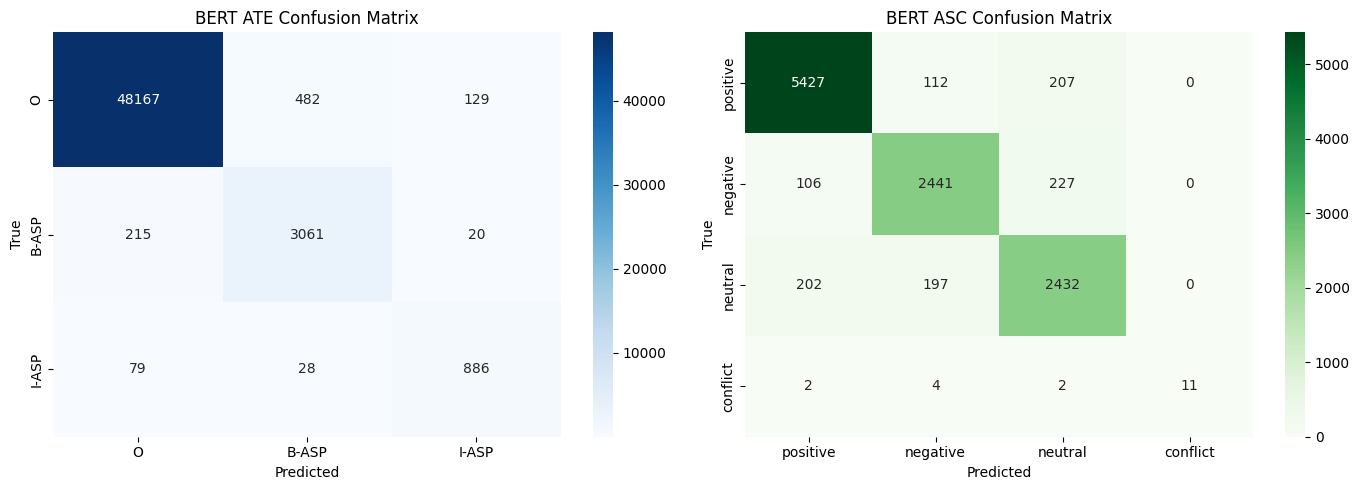

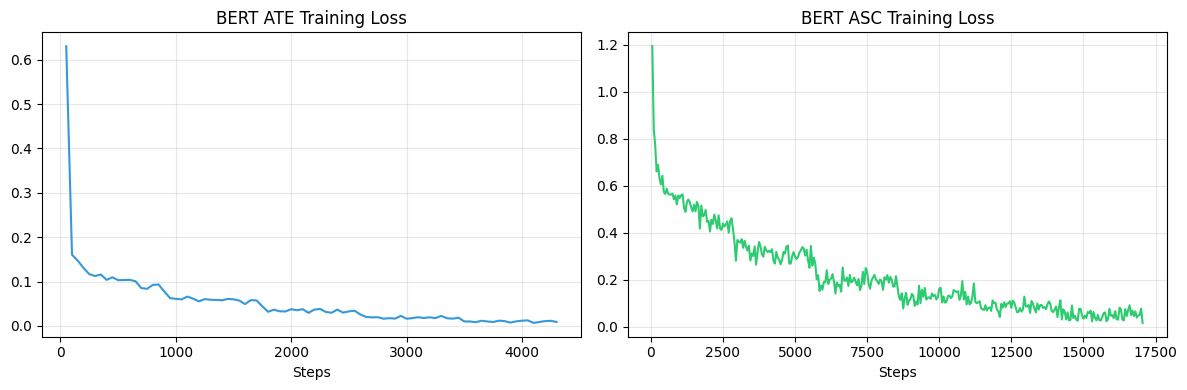

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(all_true_ate, all_pred_ate),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=ATE_LABEL_NAMES, yticklabels=ATE_LABEL_NAMES, ax=axes[0])
axes[0].set_title('BERT ATE Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(confusion_matrix(all_true_sent, all_pred_sent),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=SENT_LABEL_NAMES, yticklabels=SENT_LABEL_NAMES, ax=axes[1])
axes[1].set_title('BERT ASC Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('bert_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

# Training loss curves
def extract_loss(log_history):
    steps, losses = [], []
    for entry in log_history:
        if 'loss' in entry and 'step' in entry:
            steps.append(entry['step']); losses.append(entry['loss'])
    return steps, losses

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ate_s, ate_l = extract_loss(ate_trainer.state.log_history)
snt_s, snt_l = extract_loss(sent_trainer.state.log_history)
if ate_s:
    axes[0].plot(ate_s, ate_l, color='#3498db', linewidth=1.5)
    axes[0].set_title('BERT ATE Training Loss'); axes[0].set_xlabel('Steps'); axes[0].grid(True, alpha=0.3)
if snt_s:
    axes[1].plot(snt_s, snt_l, color='#2ecc71', linewidth=1.5)
    axes[1].set_title('BERT ASC Training Loss'); axes[1].set_xlabel('Steps'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bert_training_loss.png', dpi=120, bbox_inches='tight')
plt.show()

## 15. Save Pipeline Config

In [17]:
config = {
    'model_key':             MODEL_KEY,
    'checkpoint':            MODEL_CHECKPOINT,
    'ate_model_path':        ATE_FINAL_DIR,
    'sentiment_model_path':  SENT_FINAL_DIR,
    'ate_label_names':       ATE_LABEL_NAMES,
    'sentiment_label_names': SENT_LABEL_NAMES,
    'sentiment_label_map':   SENT_LABEL_MAP,
    'sentiment_score_map':   SCORE_MAP,
    'ate_f1':   round(accuracy_score(all_true_ate,  all_pred_ate),  4),
    'sent_acc': round(accuracy_score(all_true_sent, all_pred_sent), 4),
}
with open(f'pipeline_config_{MODEL_KEY}.json', 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config saved to pipeline_config_{MODEL_KEY}.json')

Config saved to pipeline_config_bert.json
